In [13]:
import numpy as np
import pandas as pd
import anndata as ad

rng = np.random.default_rng(42)

def dirichlet(alpha, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    x = rng.gamma(alpha, 1.0)
    return x / x.sum()

def simulate_sc_mixture(
    N=200,               # number of droplets
    G=10,                # number of genes
    K=3,                 # number of cell types
    pi0=0.3,             # prob(droplet is empty)
    beta=0.2,            # global smoothing
    depth_real=(500, 3000),  # depth range for real cells (uniform)
    depth_empty=(50, 200),   # depth range for empty cells (uniform)
    rng=None
):
    """
    Simulate single-cell counts from the model:

    - droplet is empty with prob pi0 → counts from ambient only
    - otherwise real:
        z ~ Cat(1/K)
        alpha_i ~ something (here: Beta(2,5) to bias toward low ambient)
        pi_i = alpha_i * a + (1 - alpha_i) * [ (1 - beta) * p_z + beta * m ]
        x_i ~ Multinomial(n_i, pi_i)
    - real cell depths differ from empty depths
    """
    if rng is None:
        rng = np.random.default_rng()

    # 1. ambient distribution
    a = dirichlet(np.ones(G), rng=rng)  # can change the prior

    # 2. cell-type distributions
    p = np.zeros((K, G))
    for k in range(K):
        # make types a bit different by shifting concentration
        base = np.ones(G)
        base[k % G] = 3.0  # give each type a "favored" gene (simple)
        p[k] = dirichlet(base, rng=rng)

    # 3. global mean over types
    m = p.mean(axis=0)

    # storage
    X = np.zeros((N, G), dtype=int)
    is_empty = np.zeros(N, dtype=bool)
    z = -np.ones(N, dtype=int)     # -1 for empty, else 0..K-1
    alpha = np.zeros(N, dtype=float)
    depth = np.zeros(N, dtype=int)

    for i in range(N):
        # empty vs real
        if rng.random() < pi0:
            # empty droplet
            is_empty[i] = True
            z[i] = -1
            # depth for empty
            n_i = rng.integers(depth_empty[0], depth_empty[1] + 1)
            depth[i] = n_i
            # counts from ambient only
            X[i] = rng.multinomial(n_i, a)
            alpha[i] = 1.0  # conceptually all ambient
        else:
            # real droplet
            is_empty[i] = False
            # choose cell type
            z_i = rng.integers(0, K)
            z[i] = z_i
            # depth for real
            n_i = rng.integers(depth_real[0], depth_real[1] + 1)
            depth[i] = n_i
            # cell-specific ambient fraction
            # you can change this to depend on depth
            alpha_i = rng.beta(2.0, 5.0)  # mostly small
            alpha[i] = alpha_i
            # mixture for real cell
            mix_cell = (1 - beta) * p[z_i] + beta * m
            pi_i = alpha_i * a + (1 - alpha_i) * mix_cell
            # numeric safety
            pi_i = np.clip(pi_i, 1e-9, 1.0)
            pi_i = pi_i / pi_i.sum()
            X[i] = rng.multinomial(n_i, pi_i)

    out = {
        "X": X,                 # (N, G) counts
        "is_empty": is_empty,   # (N,) boolean
        "z": z,                 # (N,) -1 for empty, else 0..K-1
        "alpha": alpha,         # (N,) ambient fractions
        "depth": depth,         # (N,) total counts
        "ambient": a,           # (G,)
        "p_celltypes": p,       # (K, G)
        "global_mean": m,       # (G,)
        "beta": beta,
        "pi0": pi0,
    }
    return out


# ---- run a tiny demo ----
sim = simulate_sc_mixture(
    N=1000,
    G=50,
    K=3,
    pi0=0.1,
    beta=0.3,
    depth_real=(500, 2500),
    depth_empty=(50, 150),
    rng=rng,
)

X = sim["X"]
print("Counts shape:", X.shape)
print("Empty droplets:", sim["is_empty"].sum(), "/", X.shape[0])
print("First 5 depths:", sim["depth"][:5])
print("First 5 labels (−1=empty):", sim["z"][:5])
print("Ambient:", np.round(sim["ambient"], 3))
print("Cell-type 0:", np.round(sim["p_celltypes"][0], 3))


Counts shape: (1000, 50)
Empty droplets: 106 / 1000
First 5 depths: [ 763  731 2222 2461 1579]
First 5 labels (−1=empty): [0 1 1 1 2]
Ambient: [0.058 0.056 0.057 0.007 0.002 0.035 0.034 0.075 0.002 0.025 0.002 0.026
 0.041 0.009 0.029 0.004 0.002 0.008 0.022 0.01  0.03  0.005 0.044 0.029
 0.016 0.01  0.011 0.002 0.004 0.016 0.009 0.03  0.017 0.006 0.011 0.015
 0.008 0.008 0.021 0.007 0.032 0.033 0.026 0.002 0.027 0.032 0.027 0.007
 0.008 0.004]
Cell-type 0: [0.075 0.003 0.025 0.076 0.011 0.005 0.008 0.007 0.002 0.021 0.026 0.029
 0.101 0.04  0.031 0.02  0.011 0.001 0.018 0.012 0.029 0.038 0.006 0.001
 0.018 0.048 0.016 0.04  0.014 0.025 0.005 0.003 0.003 0.002 0.001 0.033
 0.009 0.007 0.018 0.004 0.036 0.025 0.006 0.004 0.01  0.006 0.001 0.01
 0.043 0.019]


In [19]:
def sim_to_anndata(sim):
    """
    Convert simulation dictionary into an AnnData object.
    """
    X = sim["X"]
    N, G = X.shape

    # ---- Construct obs (cell metadata) ----
    obs = pd.DataFrame({
        "is_empty": sim["is_empty"].astype(bool),
        "z": sim["z"].astype(int),
        "alpha": sim["alpha"].astype(float),
        "depth": sim["depth"].astype(int),
    }, index=[f"cell_{i}" for i in range(N)])

    # ---- Construct var (gene metadata) ----
    var = pd.DataFrame({
        "ambient_prob": sim["ambient"],
        "global_mean": sim["global_mean"],
    }, index=[f"gene_{j}" for j in range(G)])

    # ---- Unstructured metadata (uns) ----
    uns = {
        "p_celltypes": sim["p_celltypes"],  # (K, G)
        "beta": sim["beta"],
        "pi0": sim["pi0"],
    }

    # ---- Create AnnData ----
    adata = ad.AnnData(X=X, obs=obs, var=var, uns=uns)

    return adata

adata = sim_to_anndata(sim)

In [20]:
adata

AnnData object with n_obs × n_vars = 1000 × 50
    obs: 'is_empty', 'z', 'alpha', 'depth'
    var: 'ambient_prob', 'global_mean'
    uns: 'p_celltypes', 'beta', 'pi0'

In [21]:
adata.obs.head()

,is_empty,z,alpha,depth
cell_0,False,0,0.366894,763
cell_1,False,1,0.209885,731
cell_2,False,1,0.213415,2222
cell_3,False,1,0.183045,2461
cell_4,False,2,0.309395,1579


In [2]:
import numpy as np

def infer_with_frozen_ambient_and_empties(sim, K=3, max_iter=40, beta=0.3, verbose=True):
    """
    EM on *real* cells only, with:
      - ambient fixed to the true ambient
      - empty-vs-real fixed to the true empties
    This is to test whether the p_k and alpha_i parts are behaving.
    """

    X = sim["X"].astype(float)
    N, G = X.shape
    eps = 1e-9

    a = sim["ambient"].copy()           # FIXED ambient
    is_empty = sim["is_empty"].copy()   # FIXED empties
    z_true = sim["z"].copy()

    # work only on real cells
    real_mask = ~is_empty
    Xr = X[real_mask]           # (Nr, G)
    Nr = Xr.shape[0]

    # initial cell-type profiles: from truth
    p = sim["p_celltypes"].copy()   # (K, G)

    # initial responsibilities: from truth if available
    gamma_type = np.zeros((Nr, K))
    for j, i in enumerate(np.where(real_mask)[0]):
        if z_true[i] >= 0:
            gamma_type[j, z_true[i]] = 1.0
        else:
            gamma_type[j] = 1.0 / K

    # initial alpha: from truth
    alpha = sim["alpha"][real_mask].copy()

    loglike_prev = -np.inf

    for it in range(max_iter):
        m = p.mean(axis=0)

        # --- E step on real cells ---
        log_p_type = np.zeros((Nr, K))
        for k in range(K):
            pi_j = alpha[:, None] * a + (1 - alpha)[:, None] * (
                (1 - beta) * p[k] + beta * m
            )
            pi_j = np.clip(pi_j, eps, 1.0)
            pi_j /= pi_j.sum(axis=1, keepdims=True)
            log_p_type[:, k] = np.sum(Xr * np.log(pi_j), axis=1)

        # normalize over k
        log_p_type -= log_p_type.max(axis=1, keepdims=True)
        r = np.exp(log_p_type)
        r /= r.sum(axis=1, keepdims=True)
        gamma_type = r

        # --- M step on real cells ---
        # update p_k
        for k in range(K):
            p[k] = (gamma_type[:, k][:, None] * Xr).sum(axis=0) + 1.0  # smoothing
            p[k] /= p[k].sum()

        # update alpha_j by 1D search
        for j in range(Nr):
            mix_cell = (1 - beta) * (gamma_type[j] @ p) + beta * p.mean(axis=0)
            best_alpha, best_ll = alpha[j], -np.inf
            for a_try in np.linspace(0, 1, 31):
                pi_try = a_try * a + (1 - a_try) * mix_cell
                pi_try = np.clip(pi_try, eps, 1.0)
                ll = np.sum(Xr[j] * np.log(pi_try))
                if ll > best_ll:
                    best_ll, best_alpha = ll, a_try
            alpha[j] = best_alpha

        # log-likelihood on real cells
        loglike = np.sum(np.log(np.exp(log_p_type).sum(axis=1) + eps))
        if verbose:
            print(f"Iter {it+1:2d}: logL(real)={loglike:.3f}")
        if np.abs(loglike - loglike_prev) < 1e-4:
            break
        loglike_prev = loglike

    # build outputs back to full size
    alpha_hat = np.zeros(N)
    alpha_hat[real_mask] = alpha
    alpha_hat[~real_mask] = 1.0  # empties

    # predicted labels for real cells
    z_hat = np.full(N, -1)
    z_hat[real_mask] = np.argmax(gamma_type, axis=1)

    return {
        "ambient_hat": a,
        "p_hat": p,
        "alpha_hat": alpha_hat,
        "z_hat": z_hat,
        "is_empty_hat": is_empty,  # fixed
        "loglike": loglike,
    }


# ---- run it ----
fit = infer_with_frozen_ambient_and_empties(sim, K=3, max_iter=40, beta=0.3, verbose=True)

print("\n=== Ambient (should match true exactly) ===")
print("est:", np.round(fit["ambient_hat"], 3))
print("tru:", np.round(sim["ambient"], 3))

print("\n=== Cell-type distributions ===")
for k in range(3):
    print(f"\nType {k}")
    print("est:", np.round(fit["p_hat"][k], 3))
    print("tru:", np.round(sim["p_celltypes"][k], 3))

print("\n=== Alpha (first 10) ===")
for i in range(10):
    print(f"cell {i:2d}: est={fit['alpha_hat'][i]:.3f}, tru={sim['alpha'][i]:.3f}, empty={sim['is_empty'][i]}")

print("\n=== Empty (should match true) ===")
print("pred empty:", fit["is_empty_hat"].sum(), "true empty:", sim["is_empty"].sum())

print("\n=== Cell-type assignments (first 20) ===")
print("pred:", fit["z_hat"][:20])
print("true:", sim["z"][:20])


Iter  1: logL(real)=0.000
Iter  2: logL(real)=0.000

=== Ambient (should match true exactly) ===
est: [0.058 0.056 0.057 0.007 0.002 0.035 0.034 0.075 0.002 0.025 0.002 0.026
 0.041 0.009 0.029 0.004 0.002 0.008 0.022 0.01  0.03  0.005 0.044 0.029
 0.016 0.01  0.011 0.002 0.004 0.016 0.009 0.03  0.017 0.006 0.011 0.015
 0.008 0.008 0.021 0.007 0.032 0.033 0.026 0.002 0.027 0.032 0.027 0.007
 0.008 0.004]
tru: [0.058 0.056 0.057 0.007 0.002 0.035 0.034 0.075 0.002 0.025 0.002 0.026
 0.041 0.009 0.029 0.004 0.002 0.008 0.022 0.01  0.03  0.005 0.044 0.029
 0.016 0.01  0.011 0.002 0.004 0.016 0.009 0.03  0.017 0.006 0.011 0.015
 0.008 0.008 0.021 0.007 0.032 0.033 0.026 0.002 0.027 0.032 0.027 0.007
 0.008 0.004]

=== Cell-type distributions ===

Type 0
est: [0.064 0.025 0.034 0.048 0.009 0.017 0.014 0.028 0.004 0.021 0.016 0.026
 0.072 0.029 0.03  0.016 0.009 0.003 0.021 0.011 0.027 0.025 0.016 0.012
 0.018 0.033 0.014 0.029 0.012 0.024 0.01  0.014 0.009 0.005 0.013 0.028
 0.01  0.007 0.0

In [5]:
fit.keys()

dict_keys(['ambient_hat', 'p_hat', 'alpha_hat', 'z_hat', 'is_empty_hat', 'loglike'])

In [9]:
fit["z_hat"].shape

(1000,)

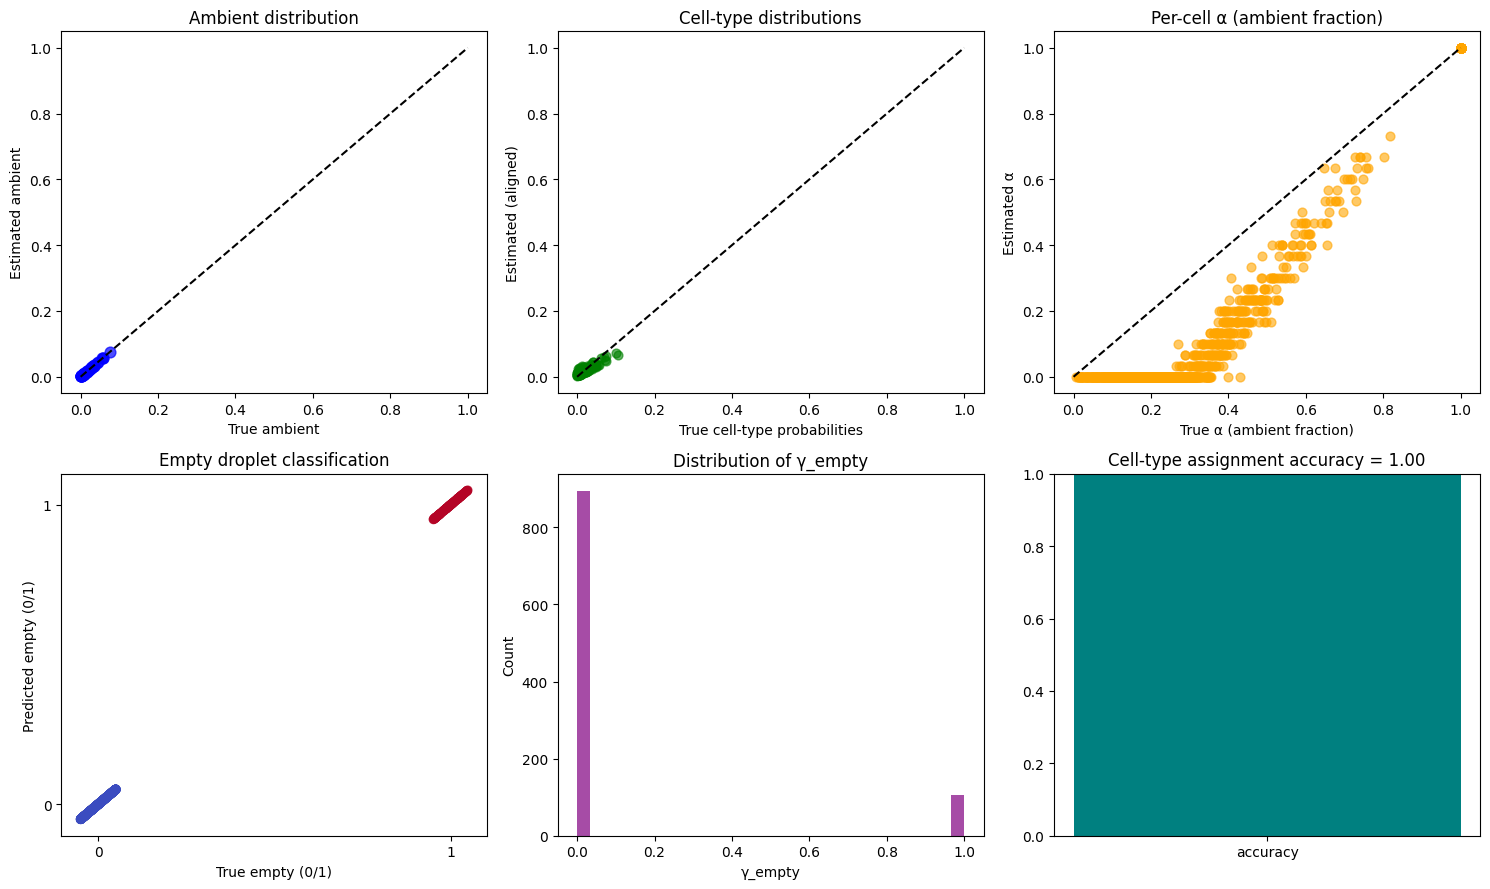


Type matching (true → inferred): [0 1 2]
Cosine similarity matrix between true & inferred types:
 [[0.945 0.661 0.62 ]
 [0.687 0.953 0.679]
 [0.613 0.644 0.938]]


In [3]:
# === Block 3: QC plots ===
import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial.distance import cdist

def qc_plots(sim, fit):
    """
    Quality-control plots comparing true vs. inferred parameters.
    Compatible with all inference variants (v2, v3, warm, frozen).
    """

    # --- Handle keys that might be missing ---
    gamma_empty = fit.get("gamma_empty", np.where(sim["is_empty"], 1.0, 0.0))
    is_empty_true = sim["is_empty"]
    is_empty_hat = fit["is_empty_hat"]
    a_true, a_hat = sim["ambient"], fit["ambient_hat"]
    p_true, p_hat = sim["p_celltypes"], fit["p_hat"]
    alpha_true, alpha_hat = sim["alpha"], fit["alpha_hat"]
    z_true, z_hat = sim["z"], fit["z_hat"]

    # --- Align inferred cell types to true ones by cosine similarity ---
    sim_matrix = 1 - cdist(p_true, p_hat, metric="cosine")
    match = sim_matrix.argmax(axis=1)
    p_hat_aligned = p_hat[match]

    # --- Create plots ---
    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    ax = axes.ravel()

    # Ambient distribution
    ax[0].scatter(a_true, a_hat, color="blue", s=60, alpha=0.7)
    ax[0].plot([0, 1], [0, 1], "k--")
    ax[0].set_xlabel("True ambient")
    ax[0].set_ylabel("Estimated ambient")
    ax[0].set_title("Ambient distribution")

    # Cell-type distributions (flatten all genes & types)
    ax[1].scatter(p_true.flatten(), p_hat_aligned.flatten(), color="green", s=40, alpha=0.6)
    ax[1].plot([0, 1], [0, 1], "k--")
    ax[1].set_xlabel("True cell-type probabilities")
    ax[1].set_ylabel("Estimated (aligned)")
    ax[1].set_title("Cell-type distributions")

    # Alpha per cell
    ax[2].scatter(alpha_true, alpha_hat, color="orange", s=40, alpha=0.6)
    ax[2].plot([0, 1], [0, 1], "k--")
    ax[2].set_xlabel("True α (ambient fraction)")
    ax[2].set_ylabel("Estimated α")
    ax[2].set_title("Per-cell α (ambient fraction)")

    # Empty vs non-empty classification
    jitter = np.random.uniform(-0.05, 0.05, size=len(is_empty_true))
    ax[3].scatter(is_empty_true + jitter, is_empty_hat + jitter, c=gamma_empty, cmap="coolwarm", alpha=0.7)
    ax[3].set_xticks([0, 1]); ax[3].set_yticks([0, 1])
    ax[3].set_xlabel("True empty (0/1)")
    ax[3].set_ylabel("Predicted empty (0/1)")
    ax[3].set_title("Empty droplet classification")

    # Gamma_empty histogram
    ax[4].hist(gamma_empty, bins=30, color="purple", alpha=0.7)
    ax[4].set_xlabel("γ_empty")
    ax[4].set_ylabel("Count")
    ax[4].set_title("Distribution of γ_empty")

    # Cell-type assignment accuracy (for real cells)
    mask_real = ~is_empty_true
    correct = (z_hat[mask_real] == z_true[mask_real])
    acc = correct.mean() if np.any(mask_real) else np.nan
    ax[5].bar(["accuracy"], [acc], color="teal")
    ax[5].set_ylim(0, 1)
    ax[5].set_title(f"Cell-type assignment accuracy = {acc:.2f}")

    plt.tight_layout()
    plt.show()

    # --- Print alignment summary ---
    print("\nType matching (true → inferred):", match)
    print("Cosine similarity matrix between true & inferred types:\n",
          np.round(sim_matrix, 3))

# ---- Run QC plots ----
qc_plots(sim, fit)


In [10]:
def reconstruct_counts(sim, fit):
    X = sim["X"].astype(float)
    N, G = X.shape

    p = fit["p_hat"]
    a = fit["ambient_hat"]
    alpha = fit["alpha_hat"]
    z = fit["z_hat"]

    X_cell = np.zeros_like(X)
    X_noise = np.zeros_like(X)
    for n in range(N):
        if z[n] == -1:  # empty
            X_noise[n] = X[n]
        else:
            g = z[n]
            total = X[n].sum()
            X_cell[n] = (1 - alpha[n]) * total * p[g]
            X_noise[n] = alpha[n] * total * a
    return X_cell, X_noise

# ---- Run reconstruction ----
X_cell, X_noise = reconstruct_counts(sim, fit)

In [11]:
X_noise

array([[2.92605969, 2.84327673, 2.90239084, ..., 0.34083583, 0.39059774,
        0.2017101 ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [8.49055852, 8.25034689, 8.42187853, ..., 0.98900463, 1.13339895,
        0.58530296],
       [1.        , 6.        , 5.        , ..., 3.        , 0.        ,
        0.        ]], shape=(1000, 50))